# Pricing Barrier Options with the COS Method

Discretely monitored up-and-out call: knocked out (payoff $\to$ rebate $R$, paid at $T$) if the asset closes at or above $H$ on any monitoring date $t_1 < \dots < t_M = T$. {cite:t}`FangOosterlee2009AM` price these with the same backward COS recursion as Bermudans:

$$c(x, t_{m-1}) = e^{-r\Delta t}\int_{\mathbb{R}} v(y,t_m)\, f(y|x)\, dy, \qquad
v(x, t_{m-1}) = \begin{cases} e^{-r(T-t_{m-1})}\, R, & x \ge h \\ c(x, t_{m-1}), & x < h \end{cases}$$

with $x=\ln(S/K)$, $h=\ln(H/K)$. The difference from the American case: the boundary $h$ is fixed in time, so the Fourier-cosine coefficients of $v$ update analytically each step — no grid, no projection. The update is a Hankel + Toeplitz matrix-vector product, and both admit FFT.

In [1]:
import sys
sys.path.insert(0, '..')
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from utils import _cos_chi, _cos_psi, _compute_domain, cos_price, bs_call_price

Terminal coefficients: the call payoff lives on $[0,h]$, the rebate on $[h,b]$ (in units of $K$)

$$V_k(t_M) = \frac{2}{b-a}\big(\chi_k(0,h) - \psi_k(0,h)\big) + \frac{2R/K}{b-a}\,\psi_k(h,b)$$

$\chi_k, \psi_k$ already sit in `utils.py` from the European pricer. The coefficient update needs one analytic sequence $m_j$ (Eqs. 34–35 of the paper).

In [2]:
def barrier_call_Vk_terminal(N, h, a, b, rebate_unit=0.0):
    # call payoff coeffs on [0,h] (knocked out above h) + rebate coeffs on [h,b]
    k = np.arange(N)
    Vk = (2.0 / (b - a)) * (_cos_chi(k, 0.0, h, a, b) - _cos_psi(k, 0.0, h, a, b))
    if rebate_unit != 0.0:
        Vk = Vk + rebate_unit * (2.0 / (b - a)) * _cos_psi(k, h, b, a, b)
    return Vk


def _mj(j, x1, x2, a, b):
    # m_j sequence, Fang-Oosterlee (2009) Eqs. (34)-(35)
    j = np.atleast_1d(j)
    bma = b - a
    out = np.empty(j.shape, dtype=complex)
    zero = (j == 0)
    out[zero] = 1j * np.pi * (x2 - x1) / bma
    jn = j[~zero]
    out[~zero] = (np.exp(1j * jn * np.pi * (x2 - a) / bma)
                  - np.exp(1j * jn * np.pi * (x1 - a) / bma)) / jn
    return out

Backward induction on the coefficients: $\hat V_k(t_m) = \hat C_k(a,h) + e^{-r(T-t_m)}\frac{2R/K}{b-a}\psi_k(h,b)$, where

$$\hat C = \frac{e^{-r\Delta t}}{\pi}\,\mathrm{Im}\{(\mathcal{M}_c + \mathcal{M}_s)\,\mathbf{u}\},
\qquad u_j = \varphi\!\left(\tfrac{j\pi}{b-a}\right)\hat V_j(t_{m+1}),\ u_0 \text{ halved}$$

$\mathcal{M}_c[k,j] = m_{k+j}$ is Hankel, $\mathcal{M}_s[k,j] = m_{j-k}$ Toeplitz. Dense version first, $O(N^2)$ per step.

In [3]:
def cos_barrier_uoc(S0, K, H, T, r, sigma, N=128, M=12, R=0.0):
    # discretely monitored up-and-out call, dense Hankel+Toeplitz, O(M N^2)
    x0, h = np.log(S0 / K), np.log(H / K)
    if x0 >= h:
        return np.exp(-r * T) * R  # knocked out at t0
    a, b = _compute_domain(x0, T, 10, sigma, r)
    h = min(h, b)
    dt = T / M
    k = np.arange(N)
    w = k * np.pi / (b - a)
    phi = np.exp(1j * w * (r - 0.5 * sigma**2) * dt - 0.5 * sigma**2 * w**2 * dt)
    psi_hb = (2.0 / (b - a)) * _cos_psi(k, h, b, a, b)
    Vk = barrier_call_Vk_terminal(N, h, a, b, rebate_unit=R / K)

    mj = _mj(np.arange(1 - N, 2 * N), a, h, a, b)  # j = 1-N .. 2N-1
    off = N - 1
    Mc = mj[off + (k[:, None] + k[None, :])]   # Hankel m_{k+j}
    Ms = mj[off + (k[None, :] - k[:, None])]   # Toeplitz m_{j-k}

    for m in range(M - 1, 0, -1):  # coefficients at t_m from t_{m+1}
        u = phi * Vk
        u[0] *= 0.5
        Vk = np.exp(-r * dt) / np.pi * np.imag((Mc + Ms) @ u)
        if R != 0.0:
            Vk = Vk + np.exp(-r * (T - m * dt)) * (R / K) * psi_hb

    F = np.real(phi * np.exp(1j * w * (x0 - a)))
    F[0] *= 0.5
    return K * np.exp(-r * dt) * np.sum(F * Vk)

# TODO down/in variant + with fft version

Both matvecs are circular convolutions (Result 2.2 of the paper): pad to length $2N$, then $\mathcal{M}_s\mathbf{u}$ is the first $N$ entries of $\mathbf{m}_s \circledast \mathbf{u}_s$ and $\mathcal{M}_c\mathbf{u}$ the first $N$ of $\mathbf{m}_c \circledast \mathbf{u}_c$, reversed. The $m_j$ don't depend on the time step, so their FFTs are computed once. $O(N\log N)$ per step.

In [4]:
def cos_barrier_uoc_fft(S0, K, H, T, r, sigma, N=128, M=12, R=0.0):
    # same recursion, matvecs via FFT circular convolution, O(M N log N)
    x0, h = np.log(S0 / K), np.log(H / K)
    if x0 >= h:
        return np.exp(-r * T) * R
    a, b = _compute_domain(x0, T, 10, sigma, r)
    h = min(h, b)
    dt = T / M
    k = np.arange(N)
    w = k * np.pi / (b - a)
    phi = np.exp(1j * w * (r - 0.5 * sigma**2) * dt - 0.5 * sigma**2 * w**2 * dt)
    psi_hb = (2.0 / (b - a)) * _cos_psi(k, h, b, a, b)
    Vk = barrier_call_Vk_terminal(N, h, a, b, rebate_unit=R / K)

    mj = _mj(np.arange(1 - N, 2 * N), a, h, a, b)
    off = N - 1
    ms = np.zeros(2 * N, dtype=complex)
    ms[0] = mj[off]                       # m_0
    ms[1:N] = mj[off - 1::-1]             # m_{-1} .. m_{1-N}  (stop must be omitted: off-N == -1 wraps)
    ms[N + 1:] = mj[off + N - 1:off:-1]   # m_{N-1} .. m_1
    mc = mj[off + 2 * N - 1:off - 1:-1] if off > 0 else mj[::-1]  # m_{2N-1} .. m_0
    fft_ms, fft_mc = np.fft.fft(ms), np.fft.fft(mc)

    zeros = np.zeros(N)
    for m in range(M - 1, 0, -1):
        u = phi * Vk
        u[0] *= 0.5
        Msu = np.fft.ifft(fft_ms * np.fft.fft(np.concatenate([u, zeros])))[:N]
        Mcu = np.fft.ifft(fft_mc * np.fft.fft(np.concatenate([zeros, u])))[:N][::-1]
        Vk = np.exp(-r * dt) / np.pi * np.imag(Msu + Mcu)
        if R != 0.0:
            Vk = Vk + np.exp(-r * (T - m * dt)) * (R / K) * psi_hb

    F = np.real(phi * np.exp(1j * w * (x0 - a)))
    F[0] *= 0.5
    return K * np.exp(-r * dt) * np.sum(F * Vk)

Does it price correctly? Brute-force check: GBM sampled exactly at the 12 monitoring dates.

In [5]:
def mc_barrier(S0, K, H, T, r, sigma, M=12, R=0.0, knock_in=False,
               n_paths=200_000, seed=7):
    # GBM at monitoring dates only; antithetic
    rng = np.random.default_rng(seed)
    dt = T / M
    Z = rng.standard_normal((n_paths // 2, M))
    Z = np.vstack([Z, -Z])
    logS = np.log(S0) + np.cumsum((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z, axis=1)
    knocked = (logS >= np.log(H)).any(axis=1)
    vanilla = np.maximum(np.exp(logS[:, -1]) - K, 0.0)
    payoff = np.where(knocked, vanilla, 0.0) if knock_in else np.where(knocked, R, vanilla)
    disc = np.exp(-r * T) * payoff
    return disc.mean(), disc.std(ddof=1) / np.sqrt(len(disc))


S0, K, H, T, r, sigma, M = 100.0, 100.0, 120.0, 1.0, 0.05, 0.2, 12

uoc = cos_barrier_uoc_fft(S0, K, H, T, r, sigma, N=512, M=M)
mc, se = mc_barrier(S0, K, H, T, r, sigma, M=M)
dense = cos_barrier_uoc(S0, K, H, T, r, sigma, N=512, M=M)
print(f"COS (FFT):   {uoc:.6f}")
print(f"COS (dense): {dense:.6f}   |fft - dense| = {abs(uoc - dense):.2e}")
print(f"MC:          {mc:.6f} +/- {se:.6f}")

COS (FFT):   1.849354
COS (dense): 1.849354   |fft - dense| = 2.66e-15
MC:          1.855432 +/- 0.009228


Up-and-in comes for free via in-out parity: UOC + UIC = vanilla.

In [6]:
cf = lambda w: np.exp(1j * w * (r - 0.5 * sigma**2) * T - 0.5 * sigma**2 * w**2 * T)
euro = cos_price(S0, K, T, r, cf, N=256, L=10, opt_type='call', std=sigma)
uic = euro - uoc
uic_mc, se_in = mc_barrier(S0, K, H, T, r, sigma, M=M, knock_in=True)
print(f"vanilla {euro:.4f} = UOC {uoc:.4f} + UIC {uic:.4f}   (MC UIC: {uic_mc:.4f} +/- {se_in:.4f})")

vanilla 10.4506 = UOC 1.8494 + UIC 8.6012   (MC UIC: 8.5842 +/- 0.0340)


How fast does it converge in $N$, and when does the FFT version pay off?

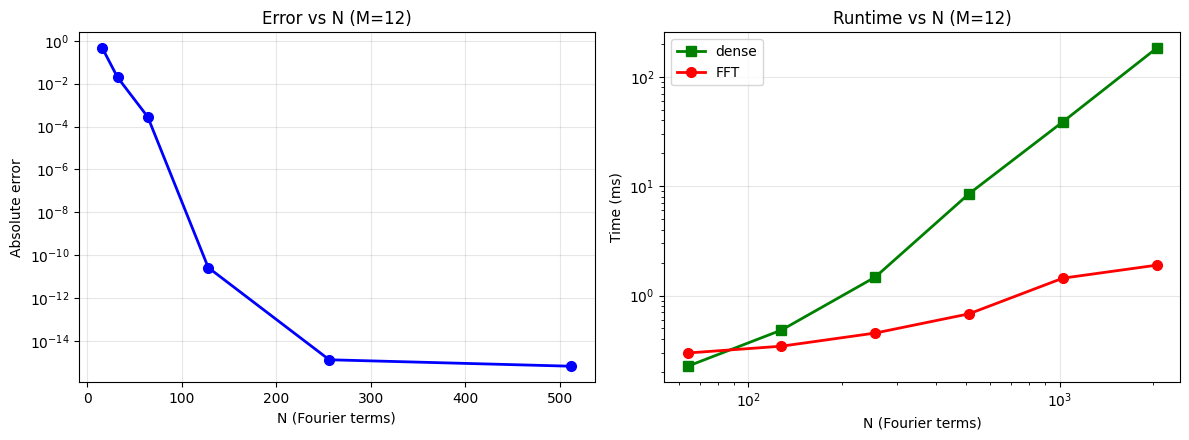

In [7]:
ref = cos_barrier_uoc_fft(S0, K, H, T, r, sigma, N=4096, M=M)
N_vals = [16, 32, 64, 128, 256, 512]
errors = [abs(cos_barrier_uoc_fft(S0, K, H, T, r, sigma, N=N, M=M) - ref) for N in N_vals]

N_time = [64, 128, 256, 512, 1024, 2048]
t_dense, t_fft = [], []
for N in N_time:
    t0 = time.time()
    for _ in range(5):
        cos_barrier_uoc(S0, K, H, T, r, sigma, N=N, M=M)
    t_dense.append((time.time() - t0) / 5 * 1000)
    t0 = time.time()
    for _ in range(5):
        cos_barrier_uoc_fft(S0, K, H, T, r, sigma, N=N, M=M)
    t_fft.append((time.time() - t0) / 5 * 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.semilogy(N_vals, errors, 'bo-', lw=2, ms=7)
ax1.set_xlabel('N (Fourier terms)')
ax1.set_ylabel('Absolute error')
ax1.set_title(f'Error vs N (M={M})')
ax1.grid(True, alpha=0.3)

ax2.loglog(N_time, t_dense, 'gs-', lw=2, ms=7, label='dense')
ax2.loglog(N_time, t_fft, 'ro-', lw=2, ms=7, label='FFT')
ax2.set_xlabel('N (Fourier terms)')
ax2.set_ylabel('Time (ms)')
ax2.set_title(f'Runtime vs N (M={M})')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

What happens as monitoring becomes continuous? Under GBM there is a closed form via the method of images: if $V$ prices the barrier-truncated call payoff $(S_T-K)^+\,\mathbf{1}_{S_T<H}$, then

$$C_{uo}(S_0) = V(S_0) - \left(\tfrac{S_0}{H}\right)^{1 - 2r/\sigma^2} V\!\left(\tfrac{H^2}{S_0}\right)$$

kills the value at $S=H$. Discrete prices should approach this from above — fewer looks at the barrier make the option worth more.

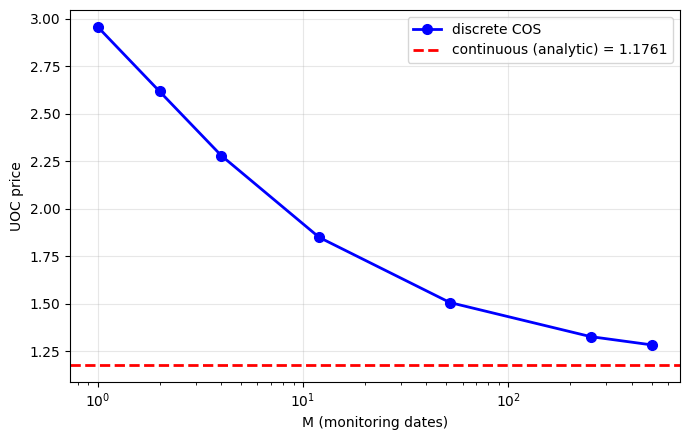

gap to continuous: M=1: 1.7818, M=2: 1.4423, M=4: 1.1041, M=12: 0.6733, M=52: 0.3302, M=252: 0.1507, M=504: 0.1066


In [8]:
def trunc_call_bs(S0, K, H, r, sigma, T):
    # e^{-rT} E[(S_T-K)^+ 1_{S_T<H}], H > K; call spread minus digital strip
    d2H = (np.log(S0 / H) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return (bs_call_price(S0, K, r, sigma, T) - bs_call_price(S0, H, r, sigma, T)
            - (H - K) * np.exp(-r * T) * norm.cdf(d2H))


def uoc_analytic(S0, K, H, r, sigma, T):
    # continuous up-and-out call (R=0, H>K), method of images
    a2 = 1.0 - 2.0 * r / sigma**2
    return (trunc_call_bs(S0, K, H, r, sigma, T)
            - (S0 / H)**a2 * trunc_call_bs(H**2 / S0, K, H, r, sigma, T))


ana = uoc_analytic(S0, K, H, r, sigma, T)
M_vals = [1, 2, 4, 12, 52, 252, 504]
prices = [cos_barrier_uoc_fft(S0, K, H, T, r, sigma, N=2048, M=m) for m in M_vals]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(M_vals, prices, 'bo-', lw=2, ms=7, label='discrete COS')
ax.axhline(ana, color='red', ls='--', lw=2, label=f'continuous (analytic) = {ana:.4f}')
ax.set_xlabel('M (monitoring dates)')
ax.set_ylabel('UOC price')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

gaps = [p - ana for p in prices]
print("gap to continuous:", ", ".join(f"M={m}: {g:.4f}" for m, g in zip(M_vals, gaps)))

The gap shrinks like $\sqrt{\Delta t}$ — even daily monitoring (M=252) sits visibly above the continuous price. That slow convergence is exactly why the Broadie–Glasserman–Kou barrier shift $H e^{0.5826\,\sigma\sqrt{\Delta t}}$ exists.

TODO: down/in variants (the $h<0$ terminal cases plus parity); swap $\varphi_{GBM}$ for `Heston_CF` — the recursion doesn't change; BGK-shifted barrier to price continuous options at small $M$.